A note book for documenting qualitative results

In [1]:
import os
import matplotlib.pyplot as plt
import torchvision
import torch
import pandas as pd
import numpy as np
import data_loaders
from torchvision import transforms
import torch
import utils

In [2]:
#import the dataset

majority_config = {'CUB_dir':r'CUB_200_2011',
                'split_file':r'CUB_200_2011/train_test_split.txt',
                'use_majority_voting':True,
                'min_class_count':10,
                'return_visibility':False}

#Center crop the image to 299x299 for Inception V3 and convert to tensor but do not normalize
transform = transforms.Compose([
    transforms.CenterCrop(299),
    transforms.ToTensor(), #implicitly divides by 255
    #transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [2, 2, 2])
    ])

normalize_transform = transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [2, 2, 2])

dataset = data_loaders.CUB_dataset(config_dict=majority_config, mode='test', transform=transform)



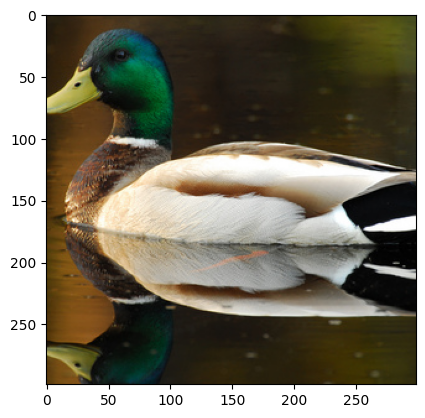

In [3]:
id = 2463

x, c, y, cordinates = dataset[id] 

#Visualize the image
plt.imshow(x.permute(1,2,0))

In [4]:

# Test the concept model with majority voting
XtoC_Model = torch.load(r'Models/ConceptModel__Seed1/outputs/best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'Models/IndependentModel_WithVal___Seed1/outputs/best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()



/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.batchnorm.BatchNorm2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.container.ModuleList' has ch

In [5]:

x_batch = x.unsqueeze(0)
x_batch = normalize_transform(x_batch)
concept_preds = torch.tensor(XtoC_Model(x_batch))

class_logits = CtoY_Model(concept_preds)
pred_class_idx = torch.argmax(class_logits).item()
pred_confidence = torch.softmax(class_logits,dim=0)[pred_class_idx].item()

# Display scrollable concept comparison table
df = utils.print_prediction(dataset, id, concept_preds, pred_class_idx, pred_confidence)

/tmp/ipykernel_187192/2117267530.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  concept_preds = torch.tensor(XtoC_Model(x_batch))


Image index: 2463  (img_id: 5049)
True class:      86 - 087.Mallard
Predicted class: 86 - 087.Mallard  (confidence: 1.000)
Concept accuracy (majority voting): 112/112
Concept accuracy (original): 95/112
Labels differ (original vs majority voting): 17/112


,Concept,Prediction,Pred (binary),True (original),True (majority voting),Vote Differs
0,has_bill_shape::dagger,-11.949,False,False,False,False
1,has_bill_shape::hooked_seabird,-12.914,False,False,False,False
2,has_bill_shape::all-purpose,-10.330,False,False,False,False
3,has_bill_shape::cone,-10.348,False,False,False,False
4,has_wing_color::brown,-9.808,False,True,False,True
5,has_wing_color::grey,-11.484,False,False,False,False
6,has_wing_color::yellow,-14.441,False,False,False,False
7,has_wing_color::black,-9.953,False,False,False,False
8,has_wing_color::white,9.976,True,True,True,False
9,has_wing_color::buff,-12.334,False,True,False,True


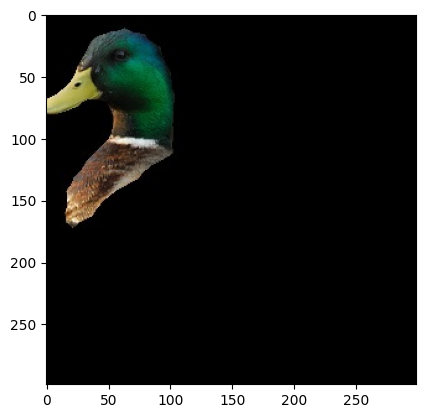

In [6]:
#Load manipulated image
from PIL import Image
ind = Image.open("mainpulated_mallard/Mallard_Manipulated2.jpg")

x = transform(ind)

plt.imshow(x.permute(1, 2, 0))

In [7]:

x_batch = x.unsqueeze(0)
x_batch = normalize_transform(x_batch)
concept_preds = torch.tensor(XtoC_Model(x_batch))

class_logits = CtoY_Model(concept_preds)
pred_class_idx = torch.argmax(class_logits).item()
pred_confidence = torch.softmax(class_logits,dim=0)[pred_class_idx].item()

# Display scrollable concept comparison table
df = utils.print_prediction(dataset, id, concept_preds, pred_class_idx, pred_confidence)
    


  

Image index: 2463  (img_id: 5049)
True class:      86 - 087.Mallard
Predicted class: 86 - 087.Mallard  (confidence: 1.000)
Concept accuracy (majority voting): 112/112
Concept accuracy (original): 95/112
Labels differ (original vs majority voting): 17/112


,Concept,Prediction,Pred (binary),True (original),True (majority voting),Vote Differs
0,has_bill_shape::dagger,-6.159,False,False,False,False
1,has_bill_shape::hooked_seabird,-5.801,False,False,False,False
2,has_bill_shape::all-purpose,-5.926,False,False,False,False
3,has_bill_shape::cone,-5.928,False,False,False,False
4,has_wing_color::brown,-6.310,False,True,False,True
5,has_wing_color::grey,-6.047,False,False,False,False
6,has_wing_color::yellow,-8.117,False,False,False,False
7,has_wing_color::black,-5.818,False,False,False,False
8,has_wing_color::white,5.473,True,True,True,False
9,has_wing_color::buff,-7.888,False,True,False,True
